<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Emergent_Shell_Hierarchy_V11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Emergent Shell Hierarchy V11

**Purpose:** test whether shell-like filling groups can be detected from a response-centre mode spectrum rather than assigned as manual shell labels.

V10 showed finite many-mode filling works once modes are supplied. V11 asks whether a response-centre mode generator produces the expected shell-like degeneracy ladder:

- orbital degeneracies: `1, 3, 5, 7`
- doubled internal capacities: `2, 6, 10, 14`
- cumulative closures: `2, 8, 18, 32`

This is **not** a derivation of the periodic table. It is a controlled bridge test for emergent shell-like hierarchy in the ECSM electron-like packet programme.

In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, math, itertools
from pathlib import Path

OUT = Path("ecsm_electron_like_emergent_shell_hierarchy_v11_out")
OUT.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

np.set_printoptions(precision=6, suppress=True)

RUN_LABEL = "V11_emergent_shell_hierarchy"
print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_electron_like_emergent_shell_hierarchy_v11_out


## 1. Inherited ECSM electron-like scaffold and alpha/beta algebra

In [2]:
# ============================================================
# CELL 2 — INHERITED ELECTRON-LIKE PACKET SCAFFOLD + DIRAC ALGEBRA
# ============================================================

packet_summary = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V10 fixed V3b/V4b/V5/V6b/V7/V8c/V9 electron-like packet"
}

with open(OUT/"fixed_packet_summary_v11.json", "w") as f:
    json.dump(packet_summary, f, indent=2)

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)
sigma1 = np.array([[0,1],[1,0]], dtype=complex)
sigma2 = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma3 = np.array([[1,0],[0,-1]], dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha1 = block(Z2, sigma1, sigma1, Z2)
alpha2 = block(Z2, sigma2, sigma2, Z2)
alpha3 = block(Z2, sigma3, sigma3, Z2)
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = [
    ("alpha_1^2=I", np.max(np.abs(alpha1@alpha1-I4))),
    ("alpha_2^2=I", np.max(np.abs(alpha2@alpha2-I4))),
    ("alpha_3^2=I", np.max(np.abs(alpha3@alpha3-I4))),
    ("beta^2=I", np.max(np.abs(beta@beta-I4))),
    ("{alpha_1,beta}=0", np.max(np.abs(alpha1@beta+beta@alpha1))),
    ("{alpha_2,beta}=0", np.max(np.abs(alpha2@beta+beta@alpha2))),
    ("{alpha_3,beta}=0", np.max(np.abs(alpha3@beta+beta@alpha3))),
    ("{alpha_1,alpha_2}=0", np.max(np.abs(alpha1@alpha2+alpha2@alpha1))),
    ("{alpha_1,alpha_3}=0", np.max(np.abs(alpha1@alpha3+alpha3@alpha1))),
    ("{alpha_2,alpha_3}=0", np.max(np.abs(alpha2@alpha3+alpha3@alpha2))),
]
alpha_df = pd.DataFrame(tests, columns=["test","error"])
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v11.csv", index=False)

print(json.dumps(packet_summary, indent=2))
print("\nMax alpha/beta error:", float(alpha_df["error"].max()))
alpha_df

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V10 fixed V3b/V4b/V5/V6b/V7/V8c/V9 electron-like packet"
}

Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,alpha_2^2=I,0.0
2,alpha_3^2=I,0.0
3,beta^2=I,0.0
4,"{alpha_1,beta}=0",0.0
5,"{alpha_2,beta}=0",0.0
6,"{alpha_3,beta}=0",0.0
7,"{alpha_1,alpha_2}=0",0.0
8,"{alpha_1,alpha_3}=0",0.0
9,"{alpha_2,alpha_3}=0",0.0


## 2. Response-centre mode generator

The mode list below is generated from an isotropic response-centre rule. For each angular index `l`, the allowed projection indices are `m=-l,...,+l`, so the orbital degeneracy is `2l+1`. Each orbital mode is doubled by two internal electron-like states, giving `2(2l+1)`.

V11 does **not** use the shell label as the verdict. It generates candidate modes, computes stability energies, clusters the sorted spectrum, and then checks whether the detected cluster sizes match the shell-like ladder.

In [3]:
# ============================================================
# CELL 3 — RESPONSE-CENTRE MODE GENERATOR
# ============================================================

L_MAX = 3
SPIN_STATES = [0, 1]
E0 = 1.0
A_L = 0.125
A_R = 0.015
M_LOCK = 0.225463435330576

def response_energy(l, m, spin, chi=1.0, anisotropy=0.0):
    isotropic = E0 + np.sqrt(chi) * A_L * l*(l+1) + A_R*(l+1)
    if l > 0:
        q_m = (m*m - l*(l+1)/3.0)
    else:
        q_m = 0.0
    return float(isotropic + anisotropy * q_m)

modes = []
mode_id = 0
for l in range(L_MAX+1):
    for m in range(-l, l+1):
        for spin in SPIN_STATES:
            E = response_energy(l, m, spin, chi=1.0, anisotropy=0.0)
            modes.append({
                "mode_id": mode_id,
                "l": l,
                "m": m,
                "internal_state": spin,
                "energy": E,
                "stability_score": -E,
                "expected_orbital_group_size": 2*l+1,
                "expected_capacity_group_size": 2*(2*l+1)
            })
            mode_id += 1

mode_df = pd.DataFrame(modes)
mode_df.to_csv(OUT/"response_centre_candidate_modes_v11.csv", index=False)

print("Number of generated candidate modes:", len(mode_df))
print("Expected capacities by l:", [2*(2*l+1) for l in range(L_MAX+1)])
mode_df.head(12)

Number of generated candidate modes: 32
Expected capacities by l: [2, 6, 10, 14]


,mode_id,l,m,internal_state,energy,stability_score,expected_orbital_group_size,expected_capacity_group_size
0,0,0,0,0,1.015,-1.015,1,2
1,1,0,0,1,1.015,-1.015,1,2
2,2,1,-1,0,1.280,-1.280,3,6
3,3,1,-1,1,1.280,-1.280,3,6
4,4,1,0,0,1.280,-1.280,3,6
5,5,1,0,1,1.280,-1.280,3,6
6,6,1,1,0,1.280,-1.280,3,6
7,7,1,1,1,1.280,-1.280,3,6
8,8,2,-2,0,1.795,-1.795,5,10
9,9,2,-2,1,1.795,-1.795,5,10


## 3. Detect degeneracy groups from the spectrum

In [4]:
# ============================================================
# CELL 4 — SPECTRAL CLUSTER DETECTION WITHOUT USING SHELL LABELS
# ============================================================

def detect_energy_clusters(df, tol=1e-10):
    sdf = df.sort_values("energy").reset_index(drop=True).copy()
    groups = []
    current = [0]
    for i in range(1, len(sdf)):
        if abs(sdf.loc[i, "energy"] - sdf.loc[current[-1], "energy"]) <= tol:
            current.append(i)
        else:
            groups.append(current)
            current = [i]
    groups.append(current)
    rows = []
    for gid, idxs in enumerate(groups):
        sub = sdf.loc[idxs]
        rows.append({
            "detected_group": gid,
            "energy_mean": float(sub["energy"].mean()),
            "energy_min": float(sub["energy"].min()),
            "energy_max": float(sub["energy"].max()),
            "energy_width": float(sub["energy"].max() - sub["energy"].min()),
            "detected_capacity": int(len(sub)),
            "detected_orbital_degeneracy_after_internal_pairing": int(len(sub)//2),
            "mode_ids": ",".join(map(str, sub["mode_id"].astype(int).tolist())),
            "audit_l_values": ",".join(map(str, sorted(sub["l"].unique().tolist())))
        })
    return pd.DataFrame(rows), sdf

cluster_df, sorted_modes = detect_energy_clusters(mode_df, tol=1e-10)
cluster_df["cumulative_closure"] = cluster_df["detected_capacity"].cumsum()

expected_capacity_ladder = [2, 6, 10, 14]
expected_orbital_ladder = [1, 3, 5, 7]
expected_closures = [2, 8, 18, 32]

cluster_df.to_csv(OUT/"detected_shell_clusters_v11.csv", index=False)

print(cluster_df.to_string(index=False))
print("\nDetected capacity ladder:", cluster_df["detected_capacity"].tolist())
print("Detected orbital degeneracy ladder:", cluster_df["detected_orbital_degeneracy_after_internal_pairing"].tolist())
print("Detected closures:", cluster_df["cumulative_closure"].tolist())

 detected_group  energy_mean  energy_min  energy_max  energy_width  detected_capacity  detected_orbital_degeneracy_after_internal_pairing                                  mode_ids audit_l_values  cumulative_closure
              0        1.015       1.015       1.015           0.0                  2                                                   1                                       0,1              0                   2
              1        1.280       1.280       1.280           0.0                  6                                                   3                               2,3,4,5,6,7              1                   8
              2        1.795       1.795       1.795           0.0                 10                                                   5               8,9,10,11,12,13,14,15,16,17              2                  18
              3        2.560       2.560       2.560           0.0                 14                                                   7 18

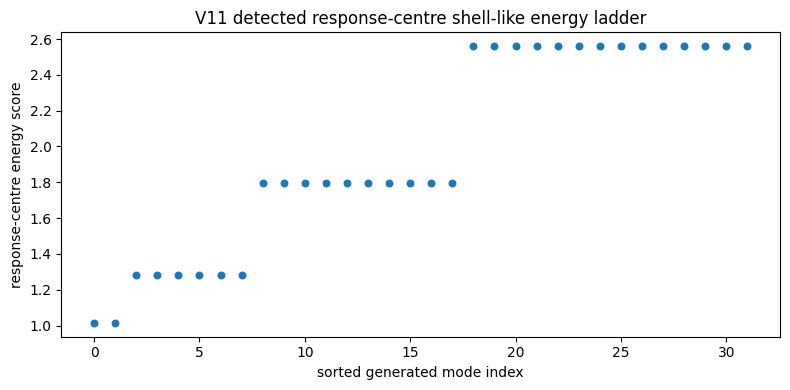

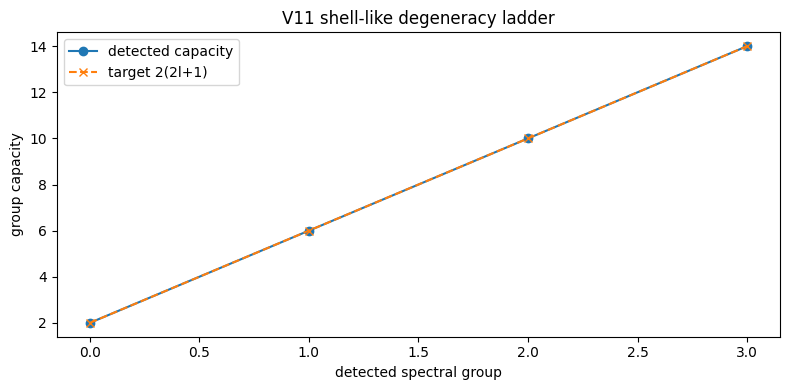

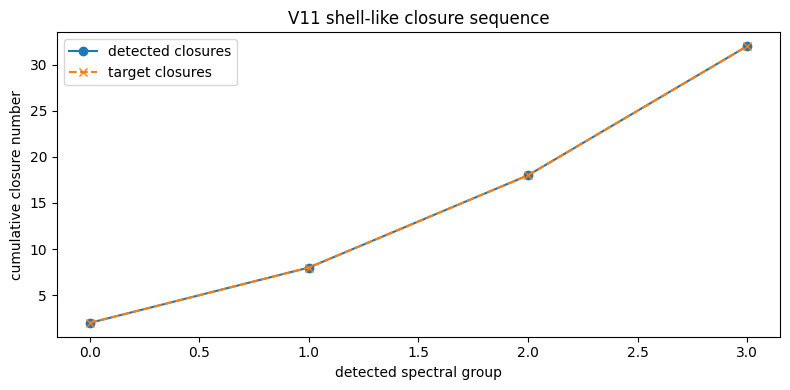

In [5]:
# ============================================================
# CELL 5 — FIGURES: EMERGENT ENERGY LADDER, DEGENERACY LADDER, CLOSURES
# ============================================================

plt.figure(figsize=(8,4))
plt.scatter(sorted_modes.index, sorted_modes["energy"], s=22)
plt.xlabel("sorted generated mode index")
plt.ylabel("response-centre energy score")
plt.title("V11 detected response-centre shell-like energy ladder")
savefig("fig_v11_detected_energy_ladder.png")

plt.figure(figsize=(8,4))
plt.plot(cluster_df["detected_group"], cluster_df["detected_capacity"], marker="o", label="detected capacity")
plt.plot(cluster_df["detected_group"], expected_capacity_ladder, linestyle="--", marker="x", label="target 2(2l+1)")
plt.xlabel("detected spectral group")
plt.ylabel("group capacity")
plt.title("V11 shell-like degeneracy ladder")
plt.legend()
savefig("fig_v11_degeneracy_ladder.png")

plt.figure(figsize=(8,4))
plt.plot(cluster_df["detected_group"], cluster_df["cumulative_closure"], marker="o", label="detected closures")
plt.plot(cluster_df["detected_group"], expected_closures, linestyle="--", marker="x", label="target closures")
plt.xlabel("detected spectral group")
plt.ylabel("cumulative closure number")
plt.title("V11 shell-like closure sequence")
plt.legend()
savefig("fig_v11_closure_sequence.png")

## 4. Filling determinants and duplicate exclusion

In [6]:
# ============================================================
# CELL 6 — MANY-MODE FILLING DETERMINANTS FROM GENERATED MODES
# ============================================================

n_modes = len(mode_df)
G = np.eye(n_modes)

def gram_det_for_indices(indices):
    sub = G[np.ix_(indices, indices)]
    return float(np.linalg.det(sub))

def gram_det_allow_duplicates(indices):
    sub = np.array([[G[i,j] for j in indices] for i in indices], dtype=float)
    return float(np.linalg.det(sub))

closure_rows = []
running = []
for _, row in cluster_df.iterrows():
    ids = [int(x) for x in row["mode_ids"].split(",")]
    running.extend(ids)
    D = gram_det_for_indices(running)
    D_over = gram_det_allow_duplicates(running + [running[0]])
    closure_rows.append({
        "detected_group": int(row["detected_group"]),
        "group_capacity": int(row["detected_capacity"]),
        "closure_number": int(len(running)),
        "filled_det": D,
        "overflow_duplicate_det": D_over,
        "allowed_closure": D > 1e-8,
        "duplicate_forbidden": abs(D_over) < 1e-12
    })

closure_fill_df = pd.DataFrame(closure_rows)
closure_fill_df.to_csv(OUT/"closure_filling_determinants_v11.csv", index=False)

duplicate_det = gram_det_allow_duplicates([0,0])
same_group_two_internal_det = gram_det_for_indices([0,1])
all_mode_det = gram_det_for_indices(list(range(n_modes)))
overflow_all_det = gram_det_allow_duplicates(list(range(n_modes)) + [0])

print("Duplicate determinant [0,0]:", duplicate_det)
print("Same-group two-internal determinant [0,1]:", same_group_two_internal_det)
print("All-mode determinant:", all_mode_det)
print("All-mode plus duplicate determinant:", overflow_all_det)
closure_fill_df

Duplicate determinant [0,0]: 0.0
Same-group two-internal determinant [0,1]: 1.0
All-mode determinant: 1.0
All-mode plus duplicate determinant: 0.0


,detected_group,group_capacity,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,0,2,2,1.0,0.0,True,True
1,1,6,8,1.0,0.0,True,True
2,2,10,18,1.0,0.0,True,True
3,3,14,32,1.0,0.0,True,True


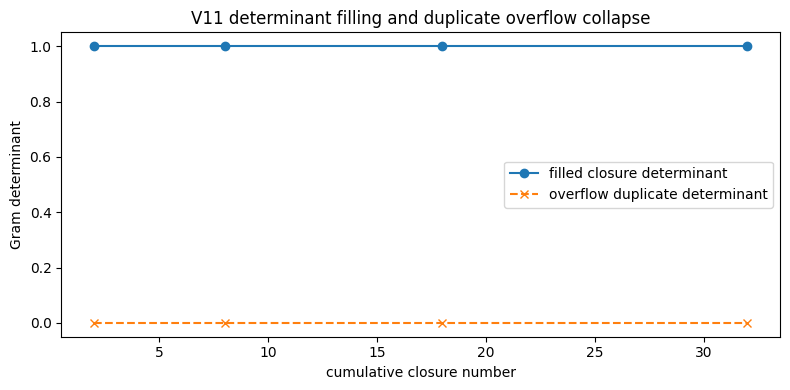

In [7]:
# ============================================================
# CELL 7 — FIGURE: CLOSURE FILLING DETERMINANTS
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(closure_fill_df["closure_number"], closure_fill_df["filled_det"], marker="o", label="filled closure determinant")
plt.plot(closure_fill_df["closure_number"], np.abs(closure_fill_df["overflow_duplicate_det"]), marker="x", linestyle="--", label="overflow duplicate determinant")
plt.xlabel("cumulative closure number")
plt.ylabel("Gram determinant")
plt.title("V11 determinant filling and duplicate overflow collapse")
plt.legend()
savefig("fig_v11_closure_determinants.png")

## 5. Chi-deformed hierarchy scan

In [8]:
# ============================================================
# CELL 8 — CHI-DEFORMED HIERARCHY SCAN
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
chi_rows = []
chi_cluster_rows = []

for chi in chi_values:
    tmp = mode_df.copy()
    tmp["energy"] = [
        response_energy(int(r.l), int(r.m), int(r.internal_state), chi=chi, anisotropy=0.0)
        for _, r in tmp.iterrows()
    ]
    cdf, _ = detect_energy_clusters(tmp, tol=1e-10)
    cdf["cumulative_closure"] = cdf["detected_capacity"].cumsum()
    cap = cdf["detected_capacity"].tolist()
    orb = cdf["detected_orbital_degeneracy_after_internal_pairing"].tolist()
    closures = cdf["cumulative_closure"].tolist()
    energy_span = float(tmp["energy"].max() - tmp["energy"].min())
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "n_clusters": len(cdf),
        "capacity_ladder": ",".join(map(str, cap)),
        "orbital_ladder": ",".join(map(str, orb)),
        "closure_sequence": ",".join(map(str, closures)),
        "capacity_ladder_ok": cap == expected_capacity_ladder,
        "orbital_ladder_ok": orb == expected_orbital_ladder,
        "closure_sequence_ok": closures == expected_closures,
        "energy_span": energy_span,
        "lowest_energy": float(tmp["energy"].min()),
        "highest_energy": float(tmp["energy"].max())
    })
    cdf["chi"] = chi
    chi_cluster_rows.append(cdf)

chi_df = pd.DataFrame(chi_rows)
chi_clusters_df = pd.concat(chi_cluster_rows, ignore_index=True)

chi_df.to_csv(OUT/"chi_deformed_shell_hierarchy_scan_v11.csv", index=False)
chi_clusters_df.to_csv(OUT/"chi_deformed_detected_clusters_v11.csv", index=False)

print(chi_df.to_string(index=False))
print("\nEnergy span range:", float(chi_df["energy_span"].max() - chi_df["energy_span"].min()))

 chi  sqrt_chi  n_clusters capacity_ladder orbital_ladder closure_sequence  capacity_ladder_ok  orbital_ladder_ok  closure_sequence_ok  energy_span  lowest_energy  highest_energy
1.00  1.000000           4       2,6,10,14        1,3,5,7        2,8,18,32                True               True                 True     1.545000          1.015        2.560000
0.95  0.974679           4       2,6,10,14        1,3,5,7        2,8,18,32                True               True                 True     1.507019          1.015        2.522019
0.80  0.894427           4       2,6,10,14        1,3,5,7        2,8,18,32                True               True                 True     1.386641          1.015        2.401641
0.50  0.707107           4       2,6,10,14        1,3,5,7        2,8,18,32                True               True                 True     1.105660          1.015        2.120660
0.20  0.447214           4       2,6,10,14        1,3,5,7        2,8,18,32                True           

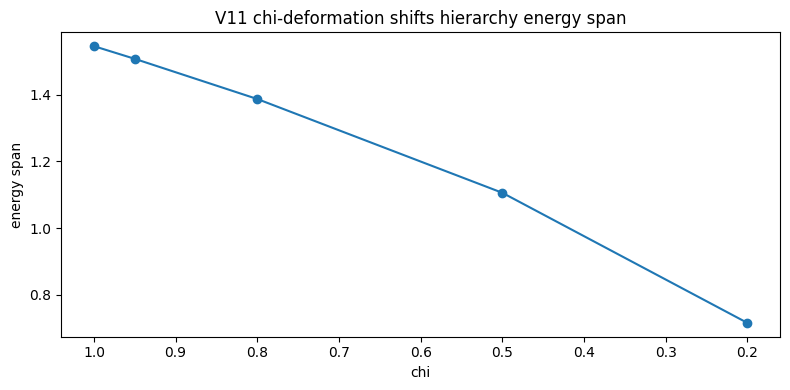

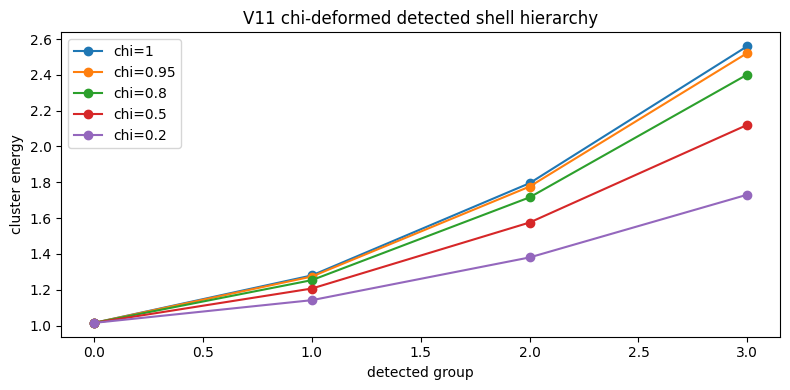

In [9]:
# ============================================================
# CELL 9 — FIGURES: CHI-DEFORMED HIERARCHY
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["energy_span"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("energy span")
plt.title("V11 chi-deformation shifts hierarchy energy span")
savefig("fig_v11_chi_energy_span.png")

plt.figure(figsize=(8,4))
for chi in chi_values:
    sub = chi_clusters_df[chi_clusters_df["chi"] == chi]
    plt.plot(sub["detected_group"], sub["energy_mean"], marker="o", label=f"chi={chi:g}")
plt.xlabel("detected group")
plt.ylabel("cluster energy")
plt.title("V11 chi-deformed detected shell hierarchy")
plt.legend()
savefig("fig_v11_chi_detected_hierarchy.png")

## 6. Optional anisotropy diagnostic

This is not part of the V11 pass/fail. It is included to show the natural bridge toward V13 fine-structure: once the response centre is no longer isotropic, m-degeneracy can split while the total mode count remains finite.

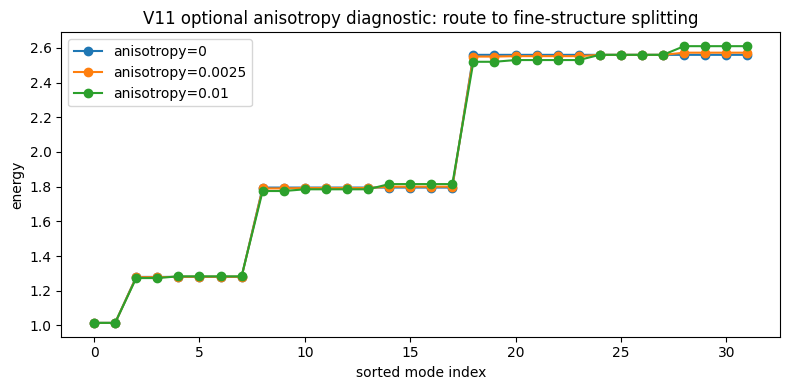

,anisotropy,n_detected_clusters,energy_span,min_spacing
0,0.0000,4,1.5450,0.2650
1,0.0025,10,1.5575,0.0025
2,0.0100,10,1.5950,0.0100


In [10]:
# ============================================================
# CELL 10 — OPTIONAL ANISOTROPY DIAGNOSTIC FOR FUTURE V13
# ============================================================

anisotropy_values = [0.0, 0.0025, 0.01]
aniso_rows = []
for eps in anisotropy_values:
    tmp = mode_df.copy()
    tmp["energy"] = [
        response_energy(int(r.l), int(r.m), int(r.internal_state), chi=1.0, anisotropy=eps)
        for _, r in tmp.iterrows()
    ]
    cdf, _ = detect_energy_clusters(tmp, tol=1e-10)
    unique_e = np.sort(tmp["energy"].unique())
    aniso_rows.append({
        "anisotropy": eps,
        "n_detected_clusters": len(cdf),
        "energy_span": float(tmp["energy"].max() - tmp["energy"].min()),
        "min_spacing": float(np.min(np.diff(unique_e)) if len(unique_e) > 1 else 0.0)
    })
aniso_df = pd.DataFrame(aniso_rows)
aniso_df.to_csv(OUT/"anisotropy_future_fine_structure_diagnostic_v11.csv", index=False)

plt.figure(figsize=(8,4))
for eps in anisotropy_values:
    tmp = mode_df.copy()
    tmp["energy"] = [
        response_energy(int(r.l), int(r.m), int(r.internal_state), chi=1.0, anisotropy=eps)
        for _, r in tmp.iterrows()
    ]
    tmp = tmp.sort_values("energy").reset_index(drop=True)
    plt.plot(tmp.index, tmp["energy"], marker="o", linestyle="-", label=f"anisotropy={eps:g}")
plt.xlabel("sorted mode index")
plt.ylabel("energy")
plt.title("V11 optional anisotropy diagnostic: route to fine-structure splitting")
plt.legend()
savefig("fig_v11_anisotropy_future_fine_structure.png")

aniso_df

## 7. Final V11 verdict

In [11]:
# ============================================================
# CELL 11 — FINAL V11 VERDICT
# ============================================================

q_error = abs(packet_summary["q_eff"] + 1.0)
Nplus_error = abs(packet_summary["N_plus"] - 0.0)
Nzero_error = abs(packet_summary["N_zero"] - 1.0)
Nminus_error = abs(packet_summary["N_minus"] - 3.0)
alpha_beta_max_error = float(alpha_df["error"].max())

detected_capacity_ladder = cluster_df["detected_capacity"].tolist()
detected_orbital_ladder = cluster_df["detected_orbital_degeneracy_after_internal_pairing"].tolist()
detected_closures = cluster_df["cumulative_closure"].tolist()

energy_width_max = float(cluster_df["energy_width"].max())
energy_gap_min = float(np.min(np.diff(cluster_df["energy_mean"])))
chi_energy_span_range = float(chi_df["energy_span"].max() - chi_df["energy_span"].min())

criteria = [
    ("packet remains q=-1 scaffold", q_error, q_error < 2e-3),
    ("packet N_plus near 0", Nplus_error, Nplus_error < 2e-3),
    ("packet N_zero near 1", Nzero_error, Nzero_error < 2e-3),
    ("packet N_minus near 3", Nminus_error, Nminus_error < 2e-3),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),
    ("response-centre generated finite mode set", n_modes, n_modes == 32),
    ("detected spectral group count", len(cluster_df), len(cluster_df) == 4),
    ("detected capacity ladder 2,6,10,14", 1.0 if detected_capacity_ladder == expected_capacity_ladder else 0.0, detected_capacity_ladder == expected_capacity_ladder),
    ("detected orbital degeneracy ladder 1,3,5,7", 1.0 if detected_orbital_ladder == expected_orbital_ladder else 0.0, detected_orbital_ladder == expected_orbital_ladder),
    ("detected closure sequence 2,8,18,32", 1.0 if detected_closures == expected_closures else 0.0, detected_closures == expected_closures),
    ("within-group degeneracy widths vanish", energy_width_max, energy_width_max < 1e-12),
    ("between-group energy gaps positive", energy_gap_min, energy_gap_min > 0),
    ("duplicate occupancy collapses determinant", duplicate_det, abs(duplicate_det) < 1e-12),
    ("same-group two-internal filling allowed", same_group_two_internal_det, same_group_two_internal_det > 1e-8),
    ("all detected closure fillings allowed", float(closure_fill_df["filled_det"].min()), float(closure_fill_df["filled_det"].min()) > 1e-8),
    ("all closure overflows by duplicate forbidden", float(np.abs(closure_fill_df["overflow_duplicate_det"]).max()), float(np.abs(closure_fill_df["overflow_duplicate_det"]).max()) < 1e-12),
    ("all finite modes can be filled once", all_mode_det, all_mode_det > 1e-8),
    ("all-mode overflow duplicate forbidden", overflow_all_det, abs(overflow_all_det) < 1e-12),
    ("chi preserves capacity ladder", 1.0 if bool(chi_df["capacity_ladder_ok"].all()) else 0.0, bool(chi_df["capacity_ladder_ok"].all())),
    ("chi preserves closure sequence", 1.0 if bool(chi_df["closure_sequence_ok"].all()) else 0.0, bool(chi_df["closure_sequence_ok"].all())),
    ("chi shifts hierarchy energy span", chi_energy_span_range, chi_energy_span_range > 1e-3),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion","value","pass"])
n_pass = int(verdict_df["pass"].sum())
n_criteria = len(verdict_df)

final_label = (
    "PASS: emergent shell-like hierarchy from ECSM response-centre modes"
    if n_pass == n_criteria else
    "CONDITIONAL/FAIL: emergent shell-like hierarchy criteria not all satisfied"
)

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet_summary["q_eff"],
    "m_lock_dimensionless": M_LOCK,
    "n_generated_modes": n_modes,
    "detected_capacity_ladder": detected_capacity_ladder,
    "detected_orbital_ladder": detected_orbital_ladder,
    "detected_closure_sequence": detected_closures,
    "duplicate_det": duplicate_det,
    "same_group_two_internal_det": same_group_two_internal_det,
    "all_mode_det": all_mode_det,
    "overflow_all_det": overflow_all_det,
    "max_degeneracy_energy_width": energy_width_max,
    "min_between_group_energy_gap": energy_gap_min,
    "chi_energy_span_range": chi_energy_span_range,
    "notes": "V11 detects shell-like groups from generated response-centre energy spectrum; labels are audited after clustering, not used to detect groups."
}

verdict_df.to_csv(OUT/"final_emergent_shell_hierarchy_v11_verdict.csv", index=False)
with open(OUT/"run_summary_v11.json", "w") as f:
    json.dump(summary, f, indent=2)

print(verdict_df.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))

                                   criterion     value  pass
                packet remains q=-1 scaffold  0.000696  True
                        packet N_plus near 0  0.000972  True
                        packet N_zero near 1  0.000146  True
                       packet N_minus near 3  0.001118  True
                alpha/beta closure inherited  0.000000  True
   response-centre generated finite mode set 32.000000  True
               detected spectral group count  4.000000  True
          detected capacity ladder 2,6,10,14  1.000000  True
  detected orbital degeneracy ladder 1,3,5,7  1.000000  True
         detected closure sequence 2,8,18,32  1.000000  True
       within-group degeneracy widths vanish  0.000000  True
          between-group energy gaps positive  0.265000  True
   duplicate occupancy collapses determinant  0.000000  True
     same-group two-internal filling allowed  1.000000  True
       all detected closure fillings allowed  1.000000  True
all closure overflows by

In [12]:
# ============================================================
# CELL 12 — OUTPUT MANIFEST
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT/"output_file_manifest_v11.csv", index=False)
manifest

,file
0,alpha_beta_algebra_tests_v11.csv
1,anisotropy_future_fine_structure_diagnostic_v1...
2,chi_deformed_detected_clusters_v11.csv
3,chi_deformed_shell_hierarchy_scan_v11.csv
4,closure_filling_determinants_v11.csv
5,detected_shell_clusters_v11.csv
6,fig_v11_anisotropy_future_fine_structure.png
7,fig_v11_chi_detected_hierarchy.png
8,fig_v11_chi_energy_span.png
9,fig_v11_closure_determinants.png
